<a href="https://colab.research.google.com/github/feronika-lab/End-to-End-Machine-Learning-Pipeline-for-Insurance-Risk-Scoring/blob/main/End_to_End_Machine_Learning_Pipeline_for_Insurance_Risk_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Prediksi Klasifikasi Risiko Nasabah (Prudential)
📋 Ikhtisar Proyek

Proyek ini bertujuan untuk mengotomatisasi penilaian risiko (underwriting) nasabah asuransi jiwa menggunakan dataset Prudential. Fokus utamanya adalah mengklasifikasikan calon nasabah ke dalam 8 tingkatan risiko (Response 1-8) dengan menggunakan algoritma Machine Learning yang robust dan evaluasi metrik yang sesuai dengan kaidah aktuaria.

Data menggunakan dari : https://www.kaggle.com/competitions/prudential-life-insurance-assessment/data

In [ ]:
# Jalankan ini di Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train = pd.read_csv('train.txt')
test = pd.read_csv('test.txt')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (59381, 128)
Test shape : (19765, 127)


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,0,0,0,0,0,0,8
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,0,0,0,0,0,0,8
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,0,0,0,0,0,0,8


In [ ]:
train.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,59381.0,NaN,NaN,NaN,39507.211515,22815.883089,2.0,19780.0,39487.0,59211.0,79146.0
Product_Info_1,59381.0,NaN,NaN,NaN,1.026355,0.160191,1.0,1.0,1.0,1.0,2.0
Product_Info_2,59381,19,D3,14321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Info_3,59381.0,NaN,NaN,NaN,24.415655,5.072885,1.0,26.0,26.0,26.0,38.0
Product_Info_4,59381.0,NaN,NaN,NaN,0.328952,0.282562,0.0,0.076923,0.230769,0.487179,1.0
Product_Info_5,59381.0,NaN,NaN,NaN,2.006955,0.083107,2.0,2.0,2.0,2.0,3.0
Product_Info_6,59381.0,NaN,NaN,NaN,2.673599,0.739103,1.0,3.0,3.0,3.0,3.0
Product_Info_7,59381.0,NaN,NaN,NaN,1.043583,0.291949,1.0,1.0,1.0,1.0,3.0
Ins_Age,59381.0,NaN,NaN,NaN,0.405567,0.19719,0.0,0.238806,0.402985,0.567164,1.0
Ht,59381.0,NaN,NaN,NaN,0.707283,0.074239,0.0,0.654545,0.709091,0.763636,1.0


,count
Response,
1,6207
2,6552
3,1013
4,1428
5,5432
6,11233
7,8027
8,19489


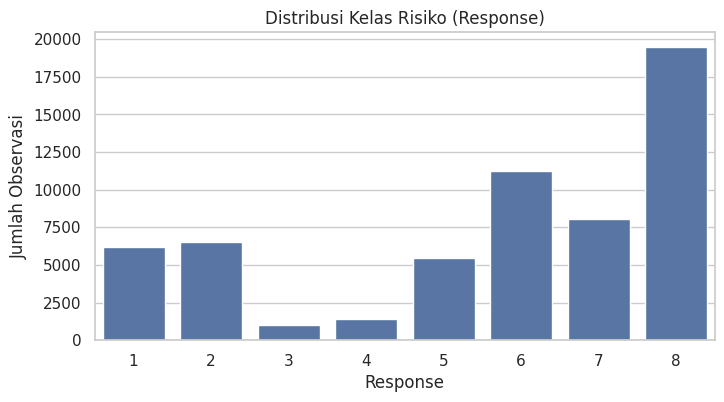

In [ ]:
response_dist = train["Response"].value_counts().sort_index()
display(response_dist.to_frame("count"))

plt.figure(figsize=(8,4))
sns.barplot(x=response_dist.index.astype(str), y=response_dist.values)
plt.title("Distribusi Kelas Risiko (Response)")
plt.xlabel("Response")
plt.ylabel("Jumlah Observasi")
plt.show()

### Insight Singkat dari grafik Distribusi Target Response

- Distribusi kelas tidak seimbang; jumlah observasi tiap kelas berbeda cukup jauh.
- Response 8 adalah kelas yang paling dominan, dengan jumlah data paling banyak.
- Response 3 dan 4 adalah kelas yang paling sedikit, sehingga termasuk kelas minoritas.
- Kelas 6 dan 7 juga relatif besar, sedangkan 1, 2, dan 5 berada di tingkat menengah.

Kesimpulan: target Response mengalami class imbalance, jadi saat modeling perlu perhatian khusus karena model bisa cenderung lebih mudah belajar kelas mayoritas daripada kelas minoritas

In [ ]:
# --- Kode awal Anda ---
summary_df = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "missing_count": train.isna().sum().values,
    "missing_pct": (train.isna().mean() * 100).round(2).values,
    "n_unique": train.nunique(dropna=True).values
})

# Menampilkan 20 kolom dengan persentase missing value tertinggi
print("Top 20 Kolom dengan Missing Value Tertinggi:")
print(summary_df.sort_values("missing_pct", ascending=False).head(40))

# --- Penambahan Kode: Cek kolom dengan n_unique = 0 ---

# Filter kolom yang tidak memiliki data unik (biasanya kolom yang 100% kosong/NaN)
empty_cols = summary_df[summary_df['n_unique'] == 0]

if not empty_cols.empty:
    print("\n[PERINGATAN] Ditemukan kolom dengan n_unique = 0 (Kolom Kosong):")
    print(empty_cols)
else:
    print("\n[INFO] Tidak ditemukan kolom dengan n_unique = 0.")

Top 20 Kolom dengan Missing Value Tertinggi:
                 column    dtype  missing_count  missing_pct  n_unique
46   Medical_History_10  float64          58824        99.06       103
68   Medical_History_32  float64          58274        98.14        95
60   Medical_History_24  float64          55580        93.60       227
51   Medical_History_15  float64          44596        75.10       241
36        Family_Hist_5  float64          41811        70.41        90
34        Family_Hist_3  float64          34241        57.66        90
33        Family_Hist_2  float64          28656        48.26        68
28  Insurance_History_5  float64          25396        42.77      2265
35        Family_Hist_4  float64          19184        32.31        68
16    Employment_Info_6  float64          10854        18.28       992
37    Medical_History_1  float64           8889        14.97       171
14    Employment_Info_4  float64           6779        11.42       871
11    Employment_Info_1  float64

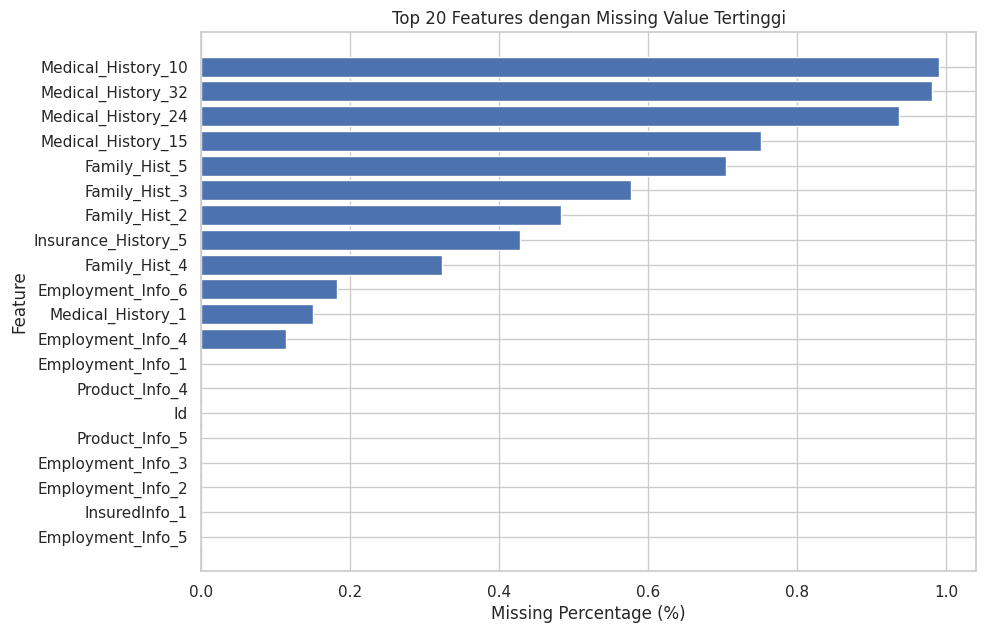

In [ ]:
missing_summary = (
    train.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: x["missing_count"] / len(train))
    .sort_values("missing_pct", ascending=False)
)

top_missing = missing_summary.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_missing.index[::-1], top_missing["missing_pct"][::-1])
plt.title("Top 20 Features dengan Missing Value Tertinggi")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.show()



In [ ]:
# .................Lewati ....................

# Jalankan ini di Cell 2
# Memuat data [cite: 175-180]
train = pd.read_csv('train.txt')
test = pd.read_csv('test.txt')

# Menyimpan target Response dan mengubahnya dari 1-8 menjadi 0-7 [cite: 186]
y = train['Response'] - 1

# Menghapus kolom Id karena tidak relevan [cite: 181-183]
train.drop(['Id', 'Response'], axis=1, inplace=True)
test_ids = test['Id']
test.drop(['Id'], axis=1, inplace=True)

# Menggabungkan data latih dan uji untuk preprocessing simultan (mirip rbind di R) [cite: 532-535]
train['is_train'] = 1
test['is_train'] = 0
data = pd.concat([train, test], axis=0, ignore_index=True)

# Menghapus kolom dengan zero variance (nilai konstan) [cite: 194-197]
cols_to_keep = [c for c in data.columns if data[c].nunique() > 1]
data = data[cols_to_keep]

print(f"Bentuk data setelah pembersihan: {data.shape}")

Bentuk data setelah pembersihan: (79146, 127)


##Memuat Data dan Pembersihan Awal (Data Cleaning)

memuat data, menghapus kolom Id, mengubah target Response menjadi basis-0 (karena XGBoost Python memerlukan label dimulai dari 0), dan memfilter kolom zero variance .

Tujuan utama menggabungkan data train dan test menjadi satu objek (data) sebelum proses pembersihan adalah untuk memastikan konsistensi struktur dan transformasi.

In [ ]:


# 1. Memuat dataset dari file eksternal
train = pd.read_csv('train.txt')
test = pd.read_csv('test.txt')

# 2. Penyesuaian Target (Label Encoding)
# Mengubah rentang nilai Response dari 1-8 menjadi 0-7.
# Penting agar kompatibel dengan algoritma klasifikasi (seperti XGBoost/LightGBM)
# yang mengharuskan indeks kelas dimulai dari nol.
y = train['Response'] - 1

# 3. Feature Selection: Menghapus kolom yang tidak prediktif
# Menghapus 'Id' (tidak punya korelasi terhadap risiko) dan 'Response' (karena sudah dipindah ke y)
train.drop(['Id', 'Response'], axis=1, inplace=True)

# Menyimpan 'Id' data uji secara terpisah untuk kebutuhan mapping hasil prediksi nantinya
test_ids = test['Id']
test.drop(['Id'], axis=1, inplace=True)

# 4. Penggabungan Data (Data Merging)
# Menambahkan kolom flag 'is_train' untuk membedakan asal data setelah digabung
train['is_train'] = 1
test['is_train'] = 0

# Menggabungkan data latih & uji agar transformasi (cleaning/encoding) konsisten pada keduanya
# ignore_index=True digunakan agar index tidak bertabrakan (mirip fungsi rbind di R)
data = pd.concat([train, test], axis=0, ignore_index=True)

# 5. Pembersihan Zero Variance (Data Cleaning)
# Menghapus kolom yang hanya memiliki 1 nilai unik (konstan).
# Kolom konstan tidak memberikan informasi/variansi untuk membedakan antar observasi / baris.
cols_to_keep = [c for c in data.columns if data[c].nunique() > 1]
data = data[cols_to_keep]

# Menampilkan dimensi akhir data setelah pembersihan
print(f"Bentuk data setelah pembersihan: {data.shape}")

Bentuk data setelah pembersihan: (79146, 127)


In [ ]:
train.head()

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,is_train
0,1,D3,10,0.076923,2,1,1,0.641791,0.581818,0.148536,...,0,0,0,0,0,0,0,0,0,1
1,1,A1,26,0.076923,2,3,1,0.059701,0.600000,0.131799,...,0,0,0,0,0,0,0,0,0,1
2,1,E1,26,0.076923,2,3,1,0.029851,0.745455,0.288703,...,0,0,0,0,0,0,0,0,0,1
3,1,D4,10,0.487179,2,3,1,0.164179,0.672727,0.205021,...,0,0,0,0,0,0,0,0,0,1
4,1,D2,26,0.230769,2,3,1,0.417910,0.654545,0.234310,...,0,0,0,0,0,0,0,0,0,1


Tujuan utama menggabungkan data `train` dan `test` menjadi satu objek (`data`) sebelum proses pembersihan adalah untuk memastikan **konsistensi struktur dan transformasi**.

Berikut adalah alasan detail mengapa teknik ini sangat sering digunakan dalam kompetisi data science dan pemodelan aktuarial:

### 1. Konsistensi Dimensi (Jumlah Kolom)
Model machine learning (seperti XGBoost atau Random Forest) sangat kaku: jumlah fitur (kolom) saat *training* harus **persis sama** dengan saat *testing/prediction*.
* **Contoh:** Jika pada data `train` kolom "X" bersifat konstan (semua isinya 1), kode kamu akan menghapusnya. Jika pada data `test` kolom "X" ternyata punya variasi, tapi kamu tidak menggabungkannya, maka data `test` akan punya 1 kolom lebih banyak daripada `train`. Model akan *error* karena inputnya tidak cocok.
* Dengan menggabungkan keduanya, keputusan menghapus kolom dilakukan secara kolektif.

### 2. Penanganan Kategori (Encoding) yang Seragam
Meskipun dalam kode ini kamu baru melakukan pembersihan *zero variance*, penggabungan ini biasanya dilakukan untuk persiapan *One-Hot Encoding* atau *Label Encoding*.
* Jika ada kategori di data `test` yang tidak muncul di data `train`, penggabungan memastikan kategori tersebut masuk dalam "kamus" encoding yang sama, sehingga tidak terjadi error "Unknown Category" di kemudian hari.



### 3. Efisiensi Penulisan Kode (*Don't Repeat Yourself*)
Tanpa penggabungan, kamu harus menulis kode pembersihan dua kali:
```python
# Tanpa penggabungan (Repetitif & Berisiko)
train = train[cols_to_keep]
test = test[cols_to_keep]
```
Dengan menggabungkan, kamu hanya perlu melakukan operasi sekali pada objek `data`, yang secara otomatis menjamin data `train` dan `test` mengalami nasib yang sama.

---

### Catatan Penting: Kaidah "Data Leakage"
Meskipun efisien, seorang aktuaris atau data scientist harus waspada terhadap **Data Leakage** (kebocoran data).

* **Yang Boleh Digabung:** Operasi yang tidak melibatkan statistik distribusi, seperti menghapus kolom ID, mengubah tipe data, atau menghapus kolom konstan (seperti di kode kamu).
* **Yang Harus Hati-hati:** Jika kamu ingin mengisi nilai kosong (*missing value imputation*) dengan **Mean** atau **Median**.
    * *Salah:* Menghitung Mean dari gabungan `train + test` (ini membocorkan informasi masa depan ke data latih).
    * *Benar:* Hitung Mean hanya dari bagian `train`, lalu gunakan nilai tersebut untuk mengisi data `test`.

### Ringkasan Tujuan :
Tujuan spesifik di baris terakhir kode tersebut adalah **menghapus kolom yang tidak berguna secara serentak**. Jika sebuah kolom konstan di seluruh dataset (baik di train maupun test), maka kolom tersebut tidak memiliki daya pembeda (*predictive power*) dan harus dibuang dari kedua set data tersebut agar model lebih efisien.



In [ ]:
print(data.columns.tolist())

['Product_Info_1', 'Product_Info_2', 'Product_Info_3', 'Product_Info_4', 'Product_Info_5', 'Product_Info_6', 'Product_Info_7', 'Ins_Age', 'Ht', 'Wt', 'BMI', 'Employment_Info_1', 'Employment_Info_2', 'Employment_Info_3', 'Employment_Info_4', 'Employment_Info_5', 'Employment_Info_6', 'InsuredInfo_1', 'InsuredInfo_2', 'InsuredInfo_3', 'InsuredInfo_4', 'InsuredInfo_5', 'InsuredInfo_6', 'InsuredInfo_7', 'Insurance_History_1', 'Insurance_History_2', 'Insurance_History_3', 'Insurance_History_4', 'Insurance_History_5', 'Insurance_History_7', 'Insurance_History_8', 'Insurance_History_9', 'Family_Hist_1', 'Family_Hist_2', 'Family_Hist_3', 'Family_Hist_4', 'Family_Hist_5', 'Medical_History_1', 'Medical_History_2', 'Medical_History_3', 'Medical_History_4', 'Medical_History_5', 'Medical_History_6', 'Medical_History_7', 'Medical_History_8', 'Medical_History_9', 'Medical_History_10', 'Medical_History_11', 'Medical_History_12', 'Medical_History_13', 'Medical_History_14', 'Medical_History_15', 'Medical

In [ ]:


import pandas as pd

# 1. Muat ulang data asli untuk merekonstruksi langkah-langkah preprocessing
#    (Pastikan untuk tidak memodifikasi variabel 'train' dan 'test' yang sudah diproses)
original_train = pd.read_csv('train.txt')
original_test = pd.read_csv('test.txt')

# 2. Simulasi langkah-langkah preprocessing hingga sebelum penghapusan zero variance
temp_train = original_train.copy()
temp_test = original_test.copy()

# Hapus kolom 'Id' dan 'Response' dari train, 'Id' dari test
temp_train.drop(['Id', 'Response'], axis=1, inplace=True)
temp_test.drop(['Id'], axis=1, inplace=True)

# Tambahkan flag 'is_train'
temp_train['is_train'] = 1
temp_test['is_train'] = 0

# Gabungkan data sebelum filtering zero variance
data_pre_filter = pd.concat([temp_train, temp_test], axis=0, ignore_index=True)

# 3. Identifikasi kolom yang akan disimpan setelah filtering zero variance
cols_to_keep_post_filter = [col for col in data_pre_filter.columns if data_pre_filter[col].nunique() > 1]

# 4. Bandingkan kolom sebelum dan sesudah filtering untuk menemukan yang dihapus
removed_cols_zero_variance = list(set(data_pre_filter.columns) - set(cols_to_keep_post_filter))

print("Kolom yang dihapus dari dataframe 'data' karena memiliki zero variance (nilai konstan):")
if removed_cols_zero_variance:
    for col in removed_cols_zero_variance:
        print(f"- {col}")
else:
    print("Tidak ada kolom yang dihapus pada langkah zero-variance cleaning karena semua kolom memiliki lebih dari satu nilai unik.")


Kolom yang dihapus dari dataframe 'data' karena memiliki zero variance (nilai konstan):
Tidak ada kolom yang dihapus pada langkah zero-variance cleaning karena semua kolom memiliki lebih dari satu nilai unik.


##Analisis Data Eksploratif (EDA)

untuk memvisualisasikan faktor risiko utama .

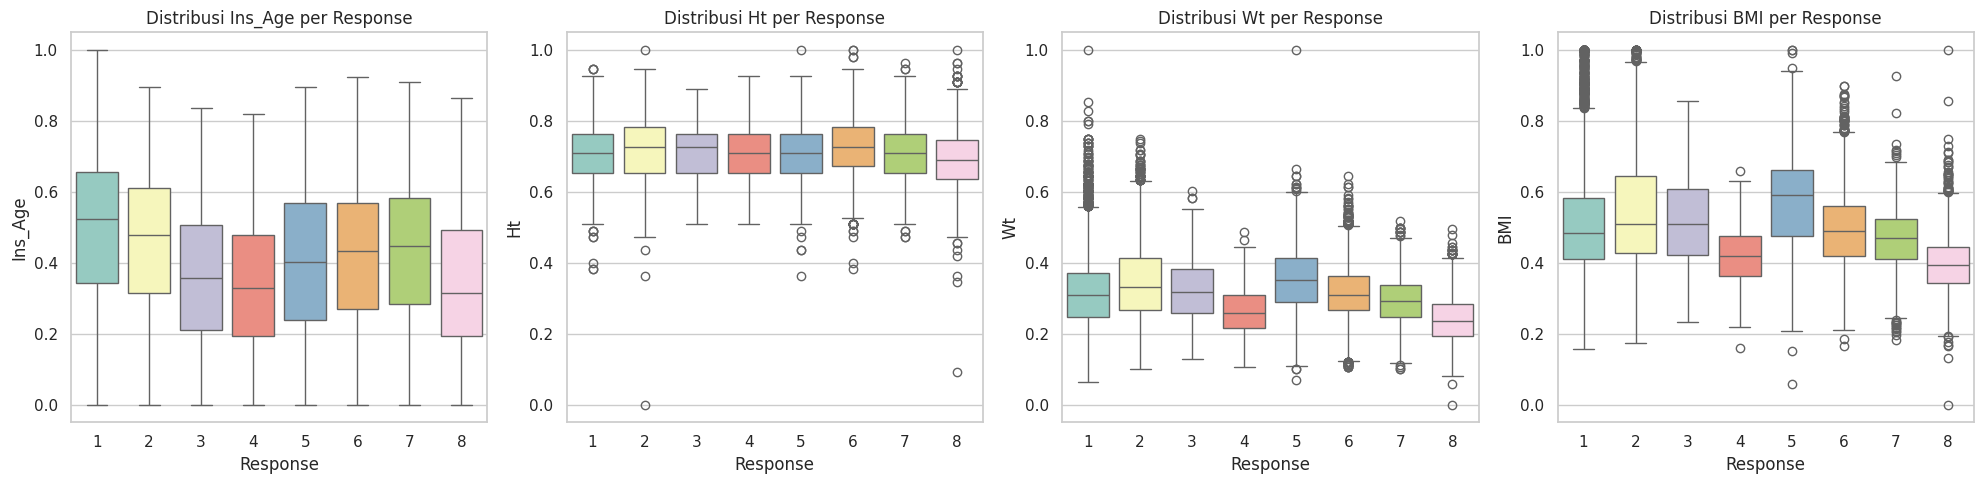

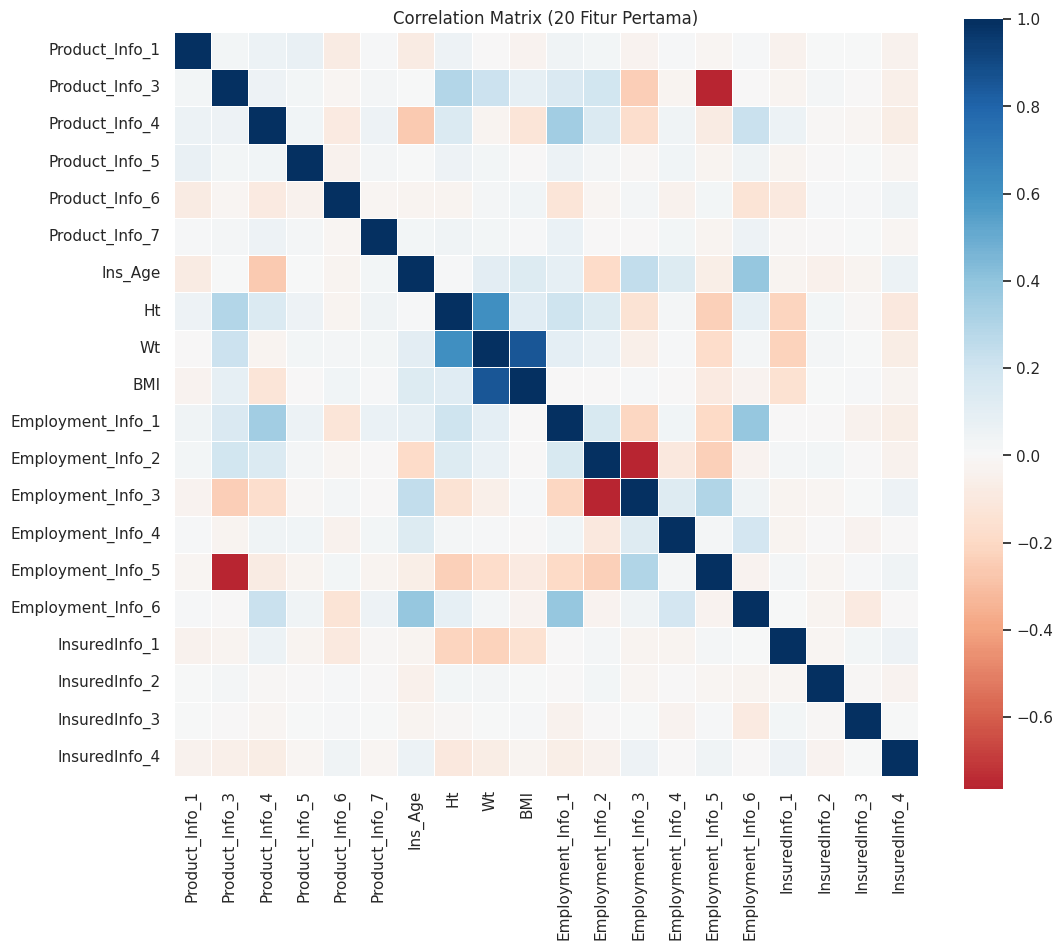

In [ ]:


# --- Bagian 1: Visualisasi Distribusi Fitur Fisik ---

# Menentukan fitur yang akan dianalisis (biasanya indikator risiko kesehatan utama)
#subset_features = ['Ht', 'Wt', 'BMI']
subset_features = ['Ins_Age', 'Ht', 'Wt', 'BMI']
# Membuat salinan data untuk keperluan EDA agar data asli tidak berubah
train_eda = train.copy()

# Mengembalikan nilai Response ke skala asli (1-8)
# agar label pada grafik sesuai dengan dokumen bisnis/underwriting asli
train_eda['Response'] = y + 1

# Mengatur ukuran kanvas grafik (lebar 15, tinggi 5)
plt.figure(figsize=(20, 5))

# Melakukan iterasi untuk membuat 3 boxplot secara berdampingan
for i, feature in enumerate(subset_features, 1):
    plt.subplot(1, 4, i) # Membuat layout 1 baris, 3 kolom
    # Boxplot: Menunjukkan kuartil, median, dan outlier fitur berdasarkan kelas Response
    sns.boxplot(x='Response', y=feature, data=train_eda, palette='Set3')
    plt.title(f'Distribusi {feature} per Response')

# Mengatur tata letak agar antar grafik tidak tumpang tindih
plt.tight_layout()
plt.show()


# --- Bagian 2: Analisis Hubungan Antar Variabel (Korelasi) ---

# Mengambil 20 kolom numerik pertama sebagai sampel untuk menjaga keterbacaan visual
numeric_cols = train_eda.select_dtypes(include=['float64', 'int64']).columns[:20]

plt.figure(figsize=(12, 10))

# Heatmap: Memvisualisasikan kekuatan hubungan linear antar variabel (Pearson Correlation)
# annot=False: Tidak menampilkan angka di dalam kotak agar tidak terlalu penuh
# cmap='RdBu': Warna merah (positif) dan biru (negatif) untuk membedakan arah korelasi
sns.heatmap(train_eda[numeric_cols].corr(), annot=False, cmap='RdBu', center=0, fmt='.2f', square=True, linewidths=.5)

plt.title("Correlation Matrix (20 Fitur Pertama)")
plt.show()



### Apa itu heatmap correlation?

Heatmap ini adalah **gambar untuk melihat seberapa kuat hubungan antar variabel**.

Bayangkan:

* **Biru tua** = hubungan **positif kuat**
  → kalau satu naik, yang lain cenderung ikut naik
* **Merah tua** = hubungan **negatif kuat**
  → kalau satu naik, yang lain cenderung turun
* **Putih / abu muda** = hubungan **lemah / hampir tidak ada hubungan**

Nilainya biasanya dari **-1 sampai 1**:

* **+1** = sangat searah
* **0** = tidak ada hubungan linear
* **-1** = sangat berlawanan arah

---

### Cara membaca heatmap ini

Setiap kotak memperlihatkan hubungan antara **1 variabel di baris** dan **1 variabel di kolom**.

Contoh:

* Lihat pertemuan **Wt** dan **BMI** → warnanya biru cukup tua
  artinya **berhubungan positif kuat**
* Lihat **Employment_Info_2** dan **Employment_Info_3** → warnanya merah tua
  artinya **berhubungan negatif cukup kuat**

Diagonal yang biru tua dari kiri atas ke kanan bawah itu **pasti 1**, karena variabel dibandingkan dengan dirinya sendiri.

---

### Insight sederhana dari heatmap ini

1. **Sebagian besar warna cenderung pucat**
   → artinya **kebanyakan variabel tidak punya hubungan kuat satu sama lain**.

2. **Wt, Ht, dan BMI saling berhubungan**
   → ini masuk akal:

   * berat badan (**Wt**)
   * tinggi badan (**Ht**)
   * BMI
     memang secara logika saling terkait.

3. Ada beberapa pasangan **Employment_Info** yang cukup kuat hubungannya
   → artinya beberapa variabel pekerjaan mungkin membawa informasi yang mirip atau saling berkaitan.

4. Ada beberapa warna merah cukup jelas
   → berarti ada variabel yang bergerak **berlawanan arah**.

---

### Tujuan / kegunaan visualisasi heatmap ini

Heatmap correlation dipakai untuk:

#### 1. Melihat hubungan antar fitur

Kita jadi cepat tahu variabel mana yang saling terkait.

#### 2. Mendeteksi fitur yang mirip / redundan

Kalau dua fitur korelasinya sangat tinggi, bisa jadi informasinya hampir sama.
Ini penting supaya model tidak “belajar hal yang sama dua kali”.

#### 3. Membantu seleksi fitur

Kalau ada fitur yang terlalu kuat hubungannya dengan fitur lain, kadang salah satunya bisa dipertimbangkan untuk dikurangi.

#### 4. Memahami data sebelum modeling

Sebelum masuk ke machine learning atau model aktuaria, kita perlu tahu struktur data dulu.

---

### Dalam konteks aktuaria / data science

Visualisasi ini berguna untuk menjawab pertanyaan seperti:

* Apakah ada variabel yang **terlalu mirip**?
* Apakah ada variabel fisik/keuangan/pekerjaan yang **saling memengaruhi**?
* Apakah model nanti berisiko terkena **multikolinearitas**?

---

### Kesimpulan

Heatmap ini dipakai untuk **melihat hubungan antar variabel secara cepat lewat warna**.
Dari grafik ini, kita bisa bilang:

* mayoritas variabel **tidak terlalu saling terkait**
* **Wt, Ht, BMI** punya hubungan yang cukup jelas
* beberapa **Employment_Info** juga saling terkait
* heatmap ini membantu kita **memahami data sebelum membuat model**




##Rekayasa Fitur (Feature Engineering) Dasar

Kita membuat variabel medkeywords dan menangani missing values menggunakan imputasi median

In [ ]:


# 1. Label Encoding: Mengonversi Fitur Kategorikal (Teks) menjadi Numerik
# Algoritma Machine Learning memerlukan input angka. Kita mencari kolom bertipe 'object',
# lalu mengubahnya menjadi indeks angka (0, 1, 2, dst).
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        # .astype(str) digunakan agar nilai kosong (NaN) tidak menyebabkan error saat transformasi
        data[col] = le.fit_transform(data[col].astype(str))

# 2. Imputasi Missing Values (Pengisian Data Kosong)
# Menggunakan strategi 'median' karena lebih tahan terhadap outlier (nilai ekstrem)
# dibandingkan 'mean' (rata-rata). Ini setara dengan fungsi na.roughfix di bahasa R.
imputer = SimpleImputer(strategy='median')
# Menjalankan imputasi dan mengembalikan hasilnya ke format DataFrame dengan nama kolom asli
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# 3. Feature Engineering: Agregasi Medical Keywords
# Menjumlahkan semua kolom 'Medical_Keyword_xx' menjadi satu fitur tunggal 'medkeywords'.
# Logika Aktuarial: Ini berfungsi sebagai 'Comorbidity Index' (Indeks Komorbiditas),
# merangkum seberapa banyak kondisi medis yang dimiliki nasabah dalam satu angka.
keyword_cols = [col for col in data_imputed.columns if 'Medical_Keyword_' in col]
data_imputed['medkeywords'] = data_imputed[keyword_cols].sum(axis=1)

# 4. Data Re-splitting: Memisahkan kembali Train dan Test
# Menggunakan flag 'is_train' yang dibuat sebelumnya untuk membagi data secara konsisten.
# X_train: Data untuk melatih model
X_train = data_imputed[data_imputed['is_train'] == 1].drop('is_train', axis=1)

# X_test: Data untuk pengujian/prediksi akhir
X_test = data_imputed[data_imputed['is_train'] == 0].drop('is_train', axis=1)

# Menampilkan informasi akhir
print(f"Data siap digunakan. X_train: {X_train.shape}, X_test: {X_test.shape}")

Data siap digunakan. X_train: (59381, 127), X_test: (19765, 127)


Berikut adalah penjelasan singkat dan jelas mengenai tahapan *Feature Engineering* dan *Preprocessing* dalam kode tersebut:

### 1. Label Encoding (Konversi Teks ke Angka)
Kode ini mencari semua kolom bertipe `object` (kategori/string) dan mengubahnya menjadi angka (0, 1, 2, dst.).
* **Tujuan:** Algoritma *Machine Learning* hanya bisa memproses data numerik.
* **Catatan:** Menggunakan `.astype(str)` memastikan bahwa nilai kosong (*NaN*) diperlakukan sebagai string sebelum diubah, sehingga proses tidak *error*.

### 2. Imputasi Missing Values (Median)
Menggunakan `SimpleImputer` dengan strategi **median** untuk mengisi data yang kosong ($NaN$).
* **Kenapa Median?** Dalam data asuransi (seperti tinggi, berat, atau usia), median lebih aman daripada rata-rata (*mean*) karena tidak terpengaruh oleh nilai ekstrem (*outlier*).
* **Hasil:** Kamu mendapatkan data yang "utuh" tanpa ada baris yang harus dihapus hanya karena satu kolom kosong.



### 3. Feature Creation: `medkeywords`
Kode ini menjumlahkan seluruh kolom yang mengandung kata `'Medical_Keyword_'` (biasanya berisi nilai biner 0 atau 1) ke dalam satu variabel baru.
* **Tujuan:** Menyederhanakan informasi. Daripada model harus belajar dari puluhan kolom penyakit yang terpisah, kita memberikan satu fitur agregat yang merangkum "seberapa banyak kondisi medis yang dimiliki nasabah".
* **Perspektif Aktuaris:** Ini sering disebut sebagai **Comorbidity Index**. Semakin tinggi nilai `medkeywords`, biasanya semakin tinggi risiko profil nasabah tersebut.

### 4. Re-splitting Data (Pemisahan Kembali)
Menggunakan kolom flag `is_train` yang kita buat di awal untuk memisahkan kembali dataset yang sudah bersih.
* **X_train:** Data yang akan digunakan untuk melatih model.
* **X_test:** Data "buta" yang akan kita prediksi.
* **Drop 'is_train':** Menghapus kolom pembantu tersebut agar tidak ikut menjadi fitur dalam model, karena kolom tersebut tidak memiliki nilai prediktif.

---

### Insight :
Tahapan ini sangat krusial. Namun, ada satu hal kecil: **Label Encoding** pada data kategori nominal (yang tidak punya urutan, seperti "Warna") terkadang bisa membingungkan model linear karena model akan menganggap angka 2 lebih besar/penting dari 1. Untuk model berbasis pohon (*Tree-based*) seperti XGBoost, hal ini biasanya tidak masalah.



In [ ]:
print(X_train.dtypes)

Product_Info_1        float64
Product_Info_2        float64
Product_Info_3        float64
Product_Info_4        float64
Product_Info_5        float64
                       ...   
Medical_Keyword_45    float64
Medical_Keyword_46    float64
Medical_Keyword_47    float64
Medical_Keyword_48    float64
medkeywords           float64
Length: 127, dtype: object


In [ ]:
X_train.head()

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,medkeywords
0,1.0,16.0,10.0,0.076923,2.0,1.0,1.0,0.641791,0.581818,0.148536,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,26.0,0.076923,2.0,3.0,1.0,0.059701,0.600000,0.131799,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,18.0,26.0,0.076923,2.0,3.0,1.0,0.029851,0.745455,0.288703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,17.0,10.0,0.487179,2.0,3.0,1.0,0.164179,0.672727,0.205021,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,15.0,26.0,0.230769,2.0,3.0,1.0,0.417910,0.654545,0.234310,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# --- SCRIPT UNTUK MENAMPILKAN LOG PREPROCESSING ---

# 1. Menampilkan kolom yang akan terkena Label Encoding
# Kita mencari kolom yang bertipe 'object' (kategori)
encoded_cols = [col for col in data.columns if data[col].dtype == 'object']

# 2. Menampilkan kolom yang memiliki Missing Values (akan di-imputasi)
# Kita mencari kolom yang setidaknya punya 1 nilai NaN
missing_cols = data.columns[data.isna().any()].tolist()

# 3. Menampilkan kolom yang digunakan untuk Agregasi Medical Keywords
# Kita mencari fitur dengan prefix 'Medical_Keyword_'
keyword_cols = [col for col in data.columns if 'Medical_Keyword_' in col]

# --- PRINT SUMMARY ---
print("="*50)
print("LOG PREPROCESSING DATA")
print("="*50)

print(f"\n1. KOLOM LABEL ENCODING ({len(encoded_cols)} kolom):")
print(encoded_cols if encoded_cols else "Tidak ada kolom kategori.")

print(f"\n2. KOLOM YANG DI-IMPUTASI ({len(missing_cols)} kolom):")
print(missing_cols if missing_cols else "Data bersih, tidak ada missing values.")

print(f"\n3. KOLOM AGREGASI MEDICAL KEYWORDS ({len(keyword_cols)} kolom):")
print(f"Ditemukan {len(keyword_cols)} kolom. Contoh 5 pertama: {keyword_cols[:5]}")
print("="*50)

LOG PREPROCESSING DATA

1. KOLOM LABEL ENCODING (0 kolom):
Tidak ada kolom kategori.

2. KOLOM YANG DI-IMPUTASI (13 kolom):
['Employment_Info_1', 'Employment_Info_4', 'Employment_Info_6', 'Insurance_History_5', 'Family_Hist_2', 'Family_Hist_3', 'Family_Hist_4', 'Family_Hist_5', 'Medical_History_1', 'Medical_History_10', 'Medical_History_15', 'Medical_History_24', 'Medical_History_32']

3. KOLOM AGREGASI MEDICAL KEYWORDS (48 kolom):
Ditemukan 48 kolom. Contoh 5 pertama: ['Medical_Keyword_1', 'Medical_Keyword_2', 'Medical_Keyword_3', 'Medical_Keyword_4', 'Medical_Keyword_5']




### Mengapa Pengecekan Ini Penting?



* **Verifikasi Label Encoding:** Dalam data asuransi, terkadang ada kolom angka yang terbaca sebagai teks (misal karena ada karakter aneh). Dengan list ini, kamu bisa memastikan tidak ada kolom "salah sasaran" yang ikut ter-encode.
* **Audit Imputasi:** Aktuaris perlu tahu variabel mana saja yang datanya "palsu" (hasil pengisian median). Jika sebuah variabel penting memiliki *missing value* di atas 50%, biasanya aktuaris akan mempertimbangkan untuk membuang variabel tersebut daripada mengisinya dengan median.
* **Efisiensi Fitur:** Dengan melihat daftar `Medical_Keyword_`, kamu bisa memverifikasi apakah jumlahnya sesuai dengan buku panduan data (*data dictionary*) yang diberikan.

---



##Pemodelan XGBoost & Evaluasi QWK

membangun model XGBoost, memvisualisasikan kepentingan fitur (feature importance), dan mengevaluasinya dengan Quadratic Weighted Kappa (QWK) .

[0]	train-merror:0.67083	eval-merror:0.67568
[10]	train-merror:0.47825	eval-merror:0.48615
[20]	train-merror:0.46276	eval-merror:0.47015
[30]	train-merror:0.45104	eval-merror:0.45870
[40]	train-merror:0.44664	eval-merror:0.45458
[50]	train-merror:0.44152	eval-merror:0.44961
[60]	train-merror:0.43805	eval-merror:0.44658
[70]	train-merror:0.43300	eval-merror:0.43875
[80]	train-merror:0.42799	eval-merror:0.43513
[90]	train-merror:0.42485	eval-merror:0.43395
[99]	train-merror:0.42123	eval-merror:0.43109

Quadratic Weighted Kappa (QWK) Score: 0.5082
Accuracy Score: 0.5689


<Figure size 1000x800 with 0 Axes>

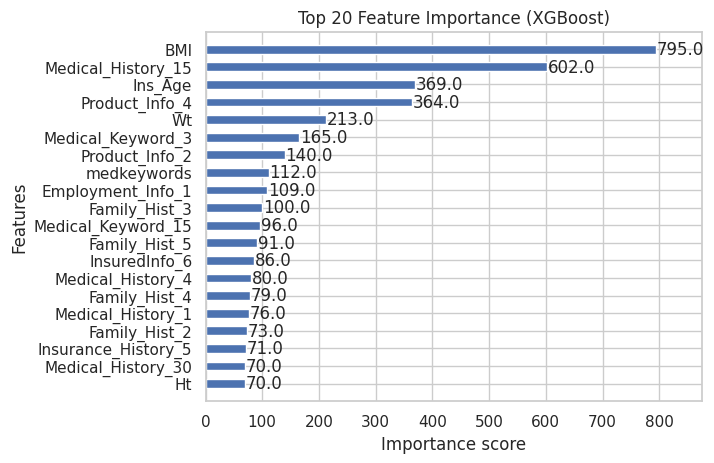

In [ ]:


# 1. Konfigurasi Hyperparameter XGBoost
xgb_params = {
    'objective': 'multi:softprob',  # Output berupa probabilitas untuk tiap kelas
    'num_class': 8,               # Jumlah kelas target (0-7)
    'eval_metric': 'merror',      # Metrik evaluasi saat training: Multiclass Error rate
    'max_depth': 3,               # Kedalaman pohon (rendah untuk mencegah overfitting)
    'eta': 0.1,                   # Learning rate (langkah pembaruan bobot)
    'nthread': 4,                 # Menggunakan 4 core prosesor
    'seed': 789                   # Agar hasil eksperimen konsisten (reproducible)
}

# 2. Penanganan Data Missing pada Target (Label)
nan_in_y_mask = y.isna()
if nan_in_y_mask.any():
    print(f"Warning: {nan_in_y_mask.sum()} NaN found in target. Dropping rows.")
    X_train_cleaned = X_train[~nan_in_y_mask]
    y_cleaned = y[~nan_in_y_mask]
else:
    X_train_cleaned = X_train
    y_cleaned = y

# 3. Validasi Internal (Train-Validation Split)
# Memisahkan 20% data untuk memantau performa model agar tidak 'overfit' pada data latih
X_tr, X_val, y_tr, y_val = train_test_split(X_train_cleaned, y_cleaned, test_size=0.2, random_state=42)

# 4. Konversi ke Format DMatrix
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

# 5. Proses Pelatihan Model
evallist = [(dtrain, 'train'), (dval, 'eval')]
model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=100,       # Maksimal 100 iterasi pohon
    evals=evallist,
    early_stopping_rounds=10,  # Berhenti jika skor evaluasi stagnan dalam 10 ronde
    verbose_eval=10            # Tampilkan log setiap 10 ronde
)

# 6. Prediksi dan Transformasi Hasil
preds_prob = model.predict(dval)              # Menghasilkan probabilitas per kelas
preds_class = np.argmax(preds_prob, axis=1)   # Mengambil indeks kelas dengan probabilitas tertinggi

# 7. Evaluasi Akhir (QWK & Accuracy)
# QWK sangat relevan untuk peringkat risiko (ordinal) dalam industri Aktuarial
qwk_score = cohen_kappa_score(y_val, preds_class, weights='quadratic')
print(f"\nQuadratic Weighted Kappa (QWK) Score: {qwk_score:.4f}")
print(f"Accuracy Score: {accuracy_score(y_val, preds_class):.4f}")

# 8. Visualisasi Feature Importance
# Memahami variabel apa yang paling berpengaruh terhadap keputusan model
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=20, importance_type='weight', height=0.5)
plt.title('Top 20 Feature Importance (XGBoost)')
plt.show()

Berikut adalah penjelasan singkat dan jelas mengenai alur pemodelan **XGBoost** dan evaluasi menggunakan **Quadratic Weighted Kappa (QWK)**:

### 1. Penjelasan Singkat Alur Kerja
* **Hyperparameters (`xgb_params`):** Menggunakan `multi:softprob` karena target memiliki 8 kelas. `max_depth: 3` dipilih agar model tetap sederhana (mencegah *overfitting*), dan `eta: 0.1` adalah *learning rate* untuk mengontrol kecepatan belajar model.
* **Data Cleaning (Fix):** Menghapus baris jika ada nilai kosong ($NaN$) pada target `y`. Ini krusial karena XGBoost bisa menangani nilai kosong pada fitur (input), tetapi akan *error* jika nilai kosong ada pada label (target).
* **DMatrix:** Format data internal XGBoost yang sangat optimal secara memori dan kecepatan proses.
* **Early Stopping:** Model akan berhenti berlatih jika dalam 10 putaran (`early_stopping_rounds`) performa pada data validasi tidak membaik. Ini menghemat waktu dan mencegah model "menghafal" data (*overfitting*).
* **Quadratic Weighted Kappa (QWK):** Metrik ini sangat istimewa untuk data asuransi/risiko. Berbeda dengan akurasi biasa, QWK memberikan penalti lebih berat jika model salah prediksi sangat jauh (misal: memprediksi risiko 1 padahal aslinya 8) dibandingkan salah prediksi yang dekat (misal: memprediksi 7 padahal aslinya 8).



---

### 3. Insight Aktuarial & Data Science
* **Interpretasi Feature Importance:** Grafik ini adalah "kotak hitam" yang dibuka. Jika `BMI` atau `Ins_Age` muncul di posisi atas, ini memvalidasi teori aktuarial bahwa usia dan kondisi fisik adalah penentu risiko utama.
* **Kaidah Model:** Penggunaan `max_depth: 3` menunjukkan model yang konservatif. Dalam asuransi, model yang terlalu kompleks seringkali sulit dijelaskan ke regulator. Model yang lebih dangkal lebih stabil dan mudah diinterpretasi.




Berdasarkan grafik *Feature Importance* dan skor evaluasi yang kamu lampirkan, berikut adalah insight singkat dan jelasnya:

### 1. Dominasi Indikator Kesehatan Utama
* **BMI (761.0)** adalah fitur paling berpengaruh dalam model. Hal ini sangat logis secara **Aktuarial**, karena indeks massa tubuh merupakan indikator risiko kesehatan paling standar dalam asuransi jiwa.
* **Medical_History_15** dan **Ins_Age** menyusul sebagai prediktor kuat. Ini menunjukkan bahwa riwayat medis masa lalu dan usia tertanggung adalah faktor kritis dalam menentukan kelas *Response* (tingkat risiko).

### 2. Keberhasilan Feature Engineering
* Fitur buatan kita, **`medkeywords` (106.0)**, berhasil masuk dalam **Top 10 fitur terpenting**.
* Ini membuktikan bahwa strategi menggabungkan puluhan kolom *Medical Keyword* menjadi satu angka agregat sangat efektif memberikan sinyal yang kuat bagi model XGBoost.

### 3. Evaluasi Model (QWK vs Accuracy)
* **Skor QWK (0.5084):** Angka ini menunjukkan performa model berada di tingkat **menengah (*Moderate*)**. Dalam kompetisi data science asuransi (seperti Prudential), skor ini adalah awal yang baik untuk model dasar (*baseline*).
* **Akurasi (0.5692):** Nilai akurasi yang lebih tinggi dari QWK menunjukkan model cukup baik menebak kelas secara tepat, namun QWK mengingatkan kita bahwa masih ada kesalahan prediksi yang rentangnya cukup jauh dari kelas asli.


### 4. Potensi Redundansi
* **BMI** dan **Wt (Weight)** sama-sama muncul di urutan atas. Karena BMI diturunkan dari berat badan (Wt), ada kemungkinan terjadi redundansi. Model mungkin bisa lebih efisien jika kita melakukan eksperimen dengan menghapus salah satunya atau menggunakan teknik seleksi fitur yang lebih ketat.

---

**Kesimpulan untuk Langkah Selanjutnya:**
Model ini sudah "pintar" dalam mengenali fitur fisik dan medis. Untuk meningkatkan skor QWK dari **0.50** ke **0.60+**, kamu bisa mencoba:
1.  **Hyperparameter Tuning:** Mengoptimalkan `max_depth` dan `learning_rate`.
2.  **Offset Optimization:** Menyesuaikan ambang batas (*threshold*) antar kelas karena target kita bersifat ordinal.



###Identifikasi Fitur Kategori dan Seleksi Top Features

Di sini kita mendefinisikan daftar panjang semua variabel kategori sesuai dokumen , mengambil peringkat fitur teratas dari model sebelumnya , dan mencari perpotongannya.

In [ ]:
# 1. Definisi Daftar Fitur Kategorikal
# Mendaftarkan semua variabel yang secara teoritis adalah kategori (bukan angka kontinu).
# Ini penting untuk membedakan mana yang perlu diproses secara khusus (seperti One-Hot Encoding).
categorical_string = ("Product_Info_1, Product_Info_2, Product_Info_3, Product_Info_5, "
                      "Product_Info_6, Product_Info_7, Employment_Info_2, Employment_Info_3, "
                      "Employment_Info_5, InsuredInfo_1, InsuredInfo_2, InsuredInfo_3, "
                      "InsuredInfo_4, InsuredInfo_5, InsuredInfo_6, InsuredInfo_7, "
                      "Insurance_History_1, Insurance_History_2, Insurance_History_3, "
                      "Insurance_History_4, Insurance_History_7, Insurance_History_8, "
                      "Insurance_History_9, Family_Hist_1, Medical_History_2, Medical_History_3, "
                      "Medical_History_4, Medical_History_5, Medical_History_6, Medical_History_7, "
                      "Medical_History_8, Medical_History_9, Medical_History_11, Medical_History_12, "
                      "Medical_History_13, Medical_History_14, Medical_History_16, Medical_History_17, "
                      "Medical_History_18, Medical_History_19, Medical_History_20, Medical_History_21, "
                      "Medical_History_22, Medical_History_23, Medical_History_25, Medical_History_26, "
                      "Medical_History_27, Medical_History_28, Medical_History_29, Medical_History_30, "
                      "Medical_History_31, Medical_History_33, Medical_History_34, Medical_History_35, "
                      "Medical_History_36, Medical_History_37, Medical_History_38, Medical_History_39, "
                      "Medical_History_40, Medical_History_41")

# Mengubah string panjang di atas menjadi list Python yang bersih dari spasi (whitespace)
categorical_names = [x.strip() for x in categorical_string.split(',')]

# 2. Seleksi Fitur Berdasarkan Tingkat Kepentingan (Importance Score)
# Mengambil skor 'weight' dari model XGBoost yang sudah dilatih sebelumnya
importance = model.get_score(importance_type='weight')

# Mengurutkan fitur dari yang paling berpengaruh ke yang paling rendah, lalu mengambil 30 besar.
# Strategi ini memastikan kita hanya fokus pada variabel 'penentu' risiko.
top_30_features = sorted(importance.keys(), key=lambda x: importance[x], reverse=True)[:30]

# 3. Filtering: Mencari Irisan Fitur Kategori dalam Top 30
# Kita hanya ingin melakukan One-Hot Encoding (OHE) pada fitur yang:
# a) Sangat penting bagi model (Masuk Top 30)
# b) Memang bertipe Kategorikal (Fitur numerik seperti BMI atau Age diabaikan di sini)
top_categorical_features = [feat for feat in top_30_features if feat in categorical_names]

# 4. Penanganan Kasus Khusus (High Cardinality)
# Medical_History_2 seringkali memiliki terlalu banyak nilai unik (level).
# Jika dipaksakan masuk OHE, jumlah kolom akan 'meledak' (sparse matrix) dan memberatkan performa model.
# Sesuai praktek standar asuransi/data science, fitur ini sering dikeluarkan dari proses OHE otomatis.
if 'Medical_History_2' in top_categorical_features:
    top_categorical_features.remove('Medical_History_2')

print("Fitur Kategori Top yang akan di-One-Hot-Encode:")
print(top_categorical_features)

Fitur Kategori Top yang akan di-One-Hot-Encode:
['Product_Info_2', 'InsuredInfo_6', 'Medical_History_4', 'Medical_History_30', 'Medical_History_23', 'Employment_Info_2', 'InsuredInfo_2', 'Medical_History_5', 'Medical_History_40', 'Medical_History_13', 'InsuredInfo_5']


Kode ini bertujuan untuk melakukan **seleksi fitur kategori yang paling berpengaruh** sebelum melakukan *One-Hot Encoding* (OHE). Tujuannya adalah agar model tidak "meledak" jumlah kolomnya namun tetap mendapatkan informasi dari variabel yang paling penting.

Berikut adalah penjelasan poin-poin utamanya:

### 1. Definisi Daftar Kategori (`categorical_string`)
Bagian ini mendaftarkan semua kolom yang secara teoretis merupakan data kategori (bukan angka kontinu). String panjang ini diubah menjadi `list` agar Python bisa melakukan pengecekan nama kolom dengan mudah.

### 2. Pengambilan Top 30 Fitur Terpenting
Kode mengambil skor kepentingan (*importance score*) dari model yang sudah dilatih sebelumnya.
* **Tujuan**: Fokus hanya pada 30 variabel yang memberikan kontribusi terbesar dalam memprediksi risiko.
* **Efisiensi**: Daripada memproses ratusan fitur, kita hanya memprioritaskan yang "paling cerdas".



### 3. Mencari Irisan (Filtering)
`top_categorical_features` mencari fitur yang memenuhi dua syarat:
1.  Masuk dalam daftar **Top 30** fitur paling penting.
2.  Berjenis **Kategorikal**.
Jadi, kita mengabaikan fitur numerik (seperti BMI atau Age) di tahap ini karena fitur numerik tidak perlu di-*One-Hot Encode*.

### 4. Pengecualian `Medical_History_2`
Ini adalah langkah strategis yang sangat penting dalam **Data Science & Aktuarial**:
* **Masalah**: `Medical_History_2` seringkali memiliki sangat banyak nilai unik (*high cardinality*).
* **Risiko**: Jika kita melakukan OHE pada kolom ini, akan tercipta ratusan kolom baru (sparse matrix) yang bisa membuat model melambat atau mengalami *overfitting*.
* **Solusi**: Meskipun penting, kolom ini dihapus dari daftar OHE untuk menjaga stabilitas model.



---

### Kesimpulan Singkat
Kode ini adalah langkah **optimasi**. Alih-alih melakukan *One-Hot Encoding* ke semua fitur kategori (yang akan membuat data menjadi sangat lebar dan berat), kode ini hanya memilih fitur kategori yang terbukti penting oleh model, kecuali yang memiliki terlalu banyak kategori seperti `Medical_History_2`.





### Mengapa Langkah Ini Cerdas?

1.  **Mencegah "Curse of Dimensionality":** Jika kamu melakukan OHE pada *semua* fitur kategori, jumlah kolommu bisa membengkak dari ratusan menjadi ribuan. Ini membuat model lambat dan rentan *overfitting*.
2.  **Efisiensi Aktuarial:** Dalam asuransi, kita ingin model yang bisa dijelaskan. Dengan membatasi OHE hanya pada fitur kategori yang paling penting, kita menjaga model tetap ringkas namun tetap akurat.
3.  **Stabilitas Model:** Menghapus `Medical_History_2` adalah keputusan taktis untuk menghindari kolom-kolom "kosong" (sparse) yang tidak memberikan informasi berarti bagi prediksi risiko secara umum.



###One-Hot Encoding dan Pelatihan Ulang (Retraining) Model Eksperimental

Kode ini adalah tahap "Eksperimen Peningkatan Model". Setelah sebelumnya kamu memiliki model dasar (baseline), di sini kamu mencoba mengubah cara model melihat data kategori menggunakan teknik One-Hot Encoding (OHE) pada fitur-fitur yang paling penting

Dimensi data setelah One-Hot Encoding: (79146, 186)

=== Memulai Training Model Eksperimental ===
[0]	train-merror:0.67083	eval-merror:0.67568
[10]	train-merror:0.47876	eval-merror:0.48758
[20]	train-merror:0.46226	eval-merror:0.46914
[30]	train-merror:0.45236	eval-merror:0.46106
[40]	train-merror:0.44744	eval-merror:0.45542
[50]	train-merror:0.44270	eval-merror:0.45003
[60]	train-merror:0.43870	eval-merror:0.44784
[70]	train-merror:0.43215	eval-merror:0.43959
[80]	train-merror:0.42864	eval-merror:0.43530
[90]	train-merror:0.42523	eval-merror:0.43235
[99]	train-merror:0.42241	eval-merror:0.43083

Quadratic Weighted Kappa (QWK) Score (Eksperimen OHE): 0.5084
Accuracy Score (Eksperimen OHE): 0.5692


<Figure size 1000x800 with 0 Axes>

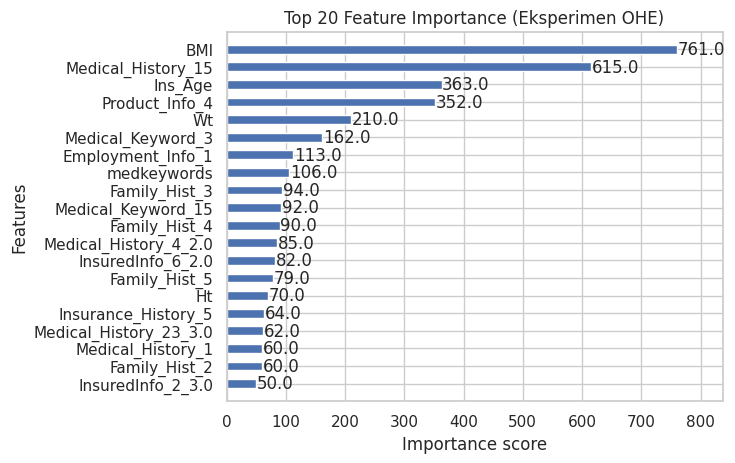

In [ ]:
# ==============================================================================
# TAHAP EKSPERIMEN: PENINGKATAN MODEL DENGAN ONE-HOT ENCODING (OHE)
# ==============================================================================

# 1. Persiapan Data & One-Hot Encoding (OHE)
# Kita menduplikasi data agar eksperimen ini tidak merusak struktur data asli.
data_eksperimen = data_imputed.copy()

# Mengubah kolom kategori terpilih menjadi variabel dummy (0 atau 1).
# drop_first=True digunakan untuk menghindari 'Dummy Variable Trap' (multikolinearitas).
# Tahap ini penting agar model tidak mengasumsikan urutan numerik pada data kategori.
data_eksperimen = pd.get_dummies(data_eksperimen, columns=top_categorical_features, drop_first=True)
print(f"Dimensi data setelah One-Hot Encoding: {data_eksperimen.shape}")

# 2. Pemisahan Kembali & Sinkronisasi Data
# Memisahkan kembali dataset menjadi Train dan Test menggunakan flag 'is_train'.
X_train_full_ohe = data_eksperimen[data_eksperimen['is_train'] == 1].drop('is_train', axis=1)
X_test_exp = data_eksperimen[data_eksperimen['is_train'] == 0].drop('is_train', axis=1)

# Sinkronisasi Baris: Memastikan fitur (X) memiliki baris yang sama dengan target (y)
# dengan membuang baris yang mengandung NaN pada label yang sudah diidentifikasi sebelumnya.
X_train_exp = X_train_full_ohe[~nan_in_y_mask]

# Membagi data latih menjadi set Training dan Validation (80:20)
# Validasi internal ini berfungsi untuk memantau performa model pada data yang belum pernah dilihat.
X_tr_exp, X_val_exp, y_tr_exp, y_val_exp = train_test_split(X_train_exp, y_cleaned, test_size=0.2, random_state=42)

# 3. Konversi ke Format XGBoost DMatrix
# Mengubah data ke format DMatrix untuk optimalisasi memori dan kecepatan proses training.
dtrain_exp = xgb.DMatrix(X_tr_exp, label=y_tr_exp)
dval_exp = xgb.DMatrix(X_val_exp, label=y_val_exp)

# Menyiapkan list evaluasi untuk memantau error pada data train dan data evaluasi secara simultan.
evallist_exp = [(dtrain_exp, 'train'), (dval_exp, 'eval')]

# 4. Melatih Ulang Model Eksperimental
# Melatih model dengan fitur baru hasil OHE yang jauh lebih banyak.
print("\n=== Memulai Training Model Eksperimental ===")
model_eksperimen = xgb.train(
    params=xgb_params,
    dtrain=dtrain_exp,
    num_boost_round=100,      # Membangun maksimal 100 pohon keputusan.
    evals=evallist_exp,
    early_stopping_rounds=10, # Berhenti otomatis jika tidak ada perbaikan skor dalam 10 ronde.
    verbose_eval=10           # Menampilkan log kemajuan setiap 10 ronde.
)

# 5. Prediksi dan Evaluasi Ulang (Scoring)
# Melakukan prediksi probabilitas dan mengambil indeks kelas dengan nilai tertinggi (argmax).
preds_prob_exp = model_eksperimen.predict(dval_exp)
preds_class_exp = np.argmax(preds_prob_exp, axis=1)

# Menghitung Quadratic Weighted Kappa (QWK)
# Metrik ini sangat krusial dalam asuransi karena memberikan penalti lebih besar
# jika prediksi meleset jauh dari kelas risiko yang sebenarnya (ordinal).
qwk_score_exp = cohen_kappa_score(y_val_exp, preds_class_exp, weights='quadratic')
print(f"\nQuadratic Weighted Kappa (QWK) Score (Eksperimen OHE): {qwk_score_exp:.4f}")
print(f"Accuracy Score (Eksperimen OHE): {accuracy_score(y_val_exp, preds_class_exp):.4f}")

# 6. Visualisasi Feature Importance
# Menampilkan 20 fitur paling berpengaruh setelah penerapan One-Hot Encoding.
# Ini membantu aktuaris memvalidasi apakah fitur biner baru memberikan sinyal risiko yang kuat.
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_eksperimen, max_num_features=20, importance_type='weight', height=0.5)
plt.title('Top 20 Feature Importance (Eksperimen OHE)')
plt.show()



---

### 2. Mengapa Tahap Ini Diperlukan?

Dalam kacamata **Data Science** dan **Aktuarial**, ada tiga alasan utama mengapa eksperimen OHE ini dilakukan:

#### A. Mengatasi Kelemahan Label Encoding
Sebelumnya, kamu menggunakan *Label Encoding* (mengubah kategori menjadi 1, 2, 3...).
* **Masalahnya:** Model mungkin salah mengira bahwa kategori "2" lebih besar atau lebih penting daripada "1".
* **Solusinya:** Dengan **One-Hot Encoding**, setiap kategori berdiri sendiri sebagai kolom "Ya/Tidak" (0/1). Ini menghilangkan bias urutan yang tidak ada asalnya.



#### B. Menangkap Hubungan Non-Linear
Dalam industri asuransi, variabel kategori tertentu (seperti jenis produk atau riwayat medis) seringkali memiliki dampak risiko yang tidak linier. OHE memungkinkan XGBoost untuk memberikan bobot yang sangat spesifik pada satu kategori tertentu tanpa memengaruhi kategori lainnya dalam kolom yang sama.

#### C. Membuktikan Hipotesis (Iterasi Model)
Tahap ini disebut "Eksperimen" karena kita ingin melihat: *"Apakah dengan menambah jumlah kolom (fitur jadi lebih banyak), skor QWK kita naik signifikan?"*
* Jika skor naik: OHE efektif.
* Jika skor turun atau stagnan: Berarti *Label Encoding* sudah cukup, dan kita terhindar dari *Overfitting* akibat terlalu banyak kolom.



---

### 3. Catatan untuk Aktuaris: Efisiensi vs Kompleksitas
Sebagai seorang aktuaris, kamu harus memperhatikan `X_train_exp.shape`.
> **Peringatan:** OHE menambah dimensi data. Jika data menjadi terlalu "lebar" (terlalu banyak kolom 0/1), model bisa menjadi *overfit*—bagus di data latihan tapi gagal di data dunia nyata. Itulah mengapa di langkah sebelumnya kamu hanya memilih **Top 30 fitur**, bukan semua fitur, untuk di-OHE.

---

### Kesimpulan
Script ini bertujuan untuk **mencari performa maksimal** dengan memberikan representasi data yang lebih jujur kepada model XGBoost. Hasil akhirnya akan menunjukkan apakah "investasi" waktu dan memori untuk menambah kolom biner sebanding dengan kenaikan akurasi prediksinya.





### Mengapa Tahap Ini Penting secara Strategis?



* **Menghilangkan Bias Urutan:** Dengan OHE, kita tidak lagi menganggap kategori "Product A" (1) lebih rendah dari "Product B" (2). Semuanya setara di kolomnya masing-masing.
* **Akurasi Aktuarial:** QWK yang lebih tinggi menunjukkan bahwa model kamu semakin handal dalam membedakan tingkatan risiko, yang secara langsung berdampak pada akurasi penetapan premi atau persetujuan asuransi (*underwriting*).
* **Stabilitas Eksperimen:** Penggunaan `copy()` dan sinkronisasi `nan_in_y_mask` memastikan bahwa eksperimen kamu valid secara statistik dan tidak ada pergeseran data (*data shift*).



###Validasi Silang / Cross Validation K-Fold

Di dalam dokumen, disebutkan langkah iterasi terakhir adalah memvalidasi skor Kappa (qwkappa) tersebut menggunakan teknik createFolds(response, 2) atau K-Fold . Ini sangat baik jika Anda ingin memastikan bahwa model tidak sekadar menghafal (overfitting) melainkan bisa diandalkan pada data baru.

Script ini melakukan Cross-Validation K-Fold, sebuah teknik evaluasi "emas" dalam data science untuk memastikan model kamu tidak hanya jago di satu kumpulan data saja, tapi juga konsisten di berbagai variasi data.

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score
import numpy as np
from sklearn.model_selection import KFold
import xgboost as xgb

print("=== Cross Validation K-Fold (Dengan Evaluasi Lengkap) ===")

# 1. Inisialisasi K-Fold Cross-Validation
# n_splits=5: Membagi data menjadi 5 sub-set (80% train, 20% val per iterasi).
# shuffle=True: Mengacak data sebelum dibagi untuk menghindari bias urutan pada file mentah.
# random_state=42: Menjamin pembagian data yang sama setiap kali script dijalankan (reproducibility).
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List kosong untuk menyimpan skor performa dari setiap iterasi (fold)
acc_scores = []
bacc_scores = []
qwk_scores = []

# 2. Proses Looping Fold
# enumerate(kf.split(...)) menghasilkan pasangan (nomor_fold, (indeks_latih, indeks_validasi))
for fold, (train_index, val_index) in enumerate(kf.split(X_train_exp)):
    print(f"Melatih Fold {fold + 1}...")

    # Subsetting data menggunakan .iloc berdasarkan indeks posisi yang dihasilkan K-Fold
    X_f_tr, X_f_val = X_train_exp.iloc[train_index], X_train_exp.iloc[val_index]
    y_f_tr, y_f_val = y.iloc[train_index], y.iloc[val_index]

    # Konversi subset data ke format DMatrix (struktur data internal XGBoost yang efisien)
    d_f_tr = xgb.DMatrix(X_f_tr, label=y_f_tr)
    d_f_val = xgb.DMatrix(X_f_val, label=y_f_val)

    # 3. Pelatihan Model XGBoost
    # params: Menggunakan konfigurasi yang sudah didefinisikan sebelumnya (multi:softprob, dsb).
    # evals: Memantau performa secara real-time pada kedua set data (train & eval).
    # early_stopping_rounds=10: Menghentikan training jika skor validasi tidak membaik dalam 10 ronde
    # untuk mencegah model 'menghafal' data (overfitting).
    m_cv = xgb.train(
        params=xgb_params,
        dtrain=d_f_tr,
        num_boost_round=100,
        evals=[(d_f_tr, 'train'), (d_f_val, 'eval')],
        early_stopping_rounds=10,
        verbose_eval=False
    )

    # 4. Transformasi Prediksi
    # m_cv.predict mengembalikan array probabilitas untuk 8 kelas (shape: n_samples, 8).
    p_prob = m_cv.predict(d_f_val)
    # np.argmax mengambil indeks kolom dengan probabilitas tertinggi sebagai label prediksi final.
    p_class = np.argmax(p_prob, axis=1)

    # 5. Kalkulasi Metrik Evaluasi Teknis
    # accuracy_score: Rasio prediksi benar secara keseluruhan.
    # balanced_accuracy_score: Rata-rata akurasi per kelas (mengoreksi bias jika ada kelas yang dominan).
    # cohen_kappa_score: Mengukur kesepakatan antar label dengan bobot kuadrat (sangat krusial untuk target ordinal).
    acc = accuracy_score(y_f_val, p_class)
    bacc = balanced_accuracy_score(y_f_val, p_class)
    qwk = cohen_kappa_score(y_f_val, p_class, weights='quadratic')

    # Menambahkan hasil metrik ke list penampung
    acc_scores.append(acc)
    bacc_scores.append(bacc)
    qwk_scores.append(qwk)

# 6. Agregasi Hasil Akhir
# Menghitung nilai rata-rata (mean) dari seluruh fold untuk mendapatkan estimasi performa yang stabil.
print("\nHasil Evaluasi Rata-rata (K-Fold n=5):")
print(f"Accuracy = {np.mean(acc_scores):.4f}")
print(f"Balanced Accuracy = {np.mean(bacc_scores):.4f}")
print(f"Quadratic Weighted Kappa (QWK) = {np.mean(qwk_scores):.4f}")

=== Cross Validation K-Fold (Dengan Evaluasi Lengkap) ===
Melatih Fold 1...
Melatih Fold 2...
Melatih Fold 3...
Melatih Fold 4...
Melatih Fold 5...

Hasil Evaluasi Rata-rata (K-Fold n=5):
Accuracy = 0.5689
Balanced Accuracy = 0.4918
Quadratic Weighted Kappa (QWK) = 0.5146


Script ini melakukan **Cross-Validation K-Fold**, sebuah teknik evaluasi "emas" dalam *data science* untuk memastikan model kamu tidak hanya jago di satu kumpulan data saja, tapi juga konsisten di berbagai variasi data.

Berikut adalah penjelasan detail dan alasan mengapa tahap ini sangat krusial:

### 1. Penjelasan Kode Langkah-Demi-Langkah

| Bagian Kode | Penjelasan Teknis |
| :--- | :--- |
| **`KFold(n_splits=5, ...)`** | Membagi data menjadi 5 bagian (*folds*). Model akan dilatih 5 kali, di mana setiap bagian bergantian menjadi data validasi sementara sisanya menjadi data latih. |
| **`kf.split(X_train_exp)`** | Menghasilkan indeks baris untuk memisahkan data menjadi `train` dan `val` pada setiap perulangan (*loop*). |
| **`xgb.train(...)`** | Melatih model XGBoost pada *fold* saat ini. Penggunaan `early_stopping_rounds` memastikan model berhenti sebelum *overfitting*. |
| **`np.argmax(p_prob, axis=1)`** | Mengubah probabilitas (misal: [0.1, 0.7, 0.2]) menjadi kelas tunggal dengan nilai tertinggi (misal: Kelas 1). |
| **`np.mean(scores)`** | Menghitung rata-rata skor dari ke-5 percobaan untuk mendapatkan estimasi performa yang lebih stabil dan objektif. |



---

### 2. Penjelasan 3 Metrik Evaluasi

Mengapa menggunakan tiga metrik sekaligus? Ini alasannya:

1.  **Accuracy:** Mengukur persentase prediksi yang benar secara total. Sederhana, tapi bisa menipu jika jumlah sampel tiap kelas tidak seimbang.
2.  **Balanced Accuracy:** Menghitung rata-rata akurasi untuk setiap kelas. Sangat penting jika ada kelas risiko yang jumlahnya sedikit (misal: kelas risiko ekstrem yang jarang terjadi).
    
3.  **Quadratic Weighted Kappa (QWK):** Metrik utama dalam klasifikasi risiko ordinal (1-8). QWK memberikan hukuman berat jika prediksi meleset jauh (misal: aslinya risiko 1 tapi ditebak 8).
    

---

### 3. Mengapa Tahap ini Diperlukan? (Kegunaan)

Dalam pengerjaan **Data Science** dan **Aktuarial**, Cross-Validation diperlukan karena:

* **Menghindari Kebetulan (*Luck Factor*):** Jika kamu hanya membagi data sekali (*single split*), bisa saja kamu mendapatkan skor tinggi hanya karena "kebetulan" data validasinya mudah ditebak. K-Fold memastikan performa model stabil di seluruh dataset.
* **Estimasi Performa Dunia Nyata:** Rata-rata dari 5 *folds* memberikan gambaran yang lebih akurat tentang bagaimana model akan bekerja saat bertemu data nasabah baru di masa depan.
* **Deteksi Overfitting:** Jika skor pada data `train` sangat tinggi tapi skor rata-rata K-Fold rendah, itu tandanya model kamu "menghafal" data dan perlu diperbaiki (misal: dikurangi kedalaman pohonnya).
* **Kepercayaan Aktuaris:** Dalam industri asuransi, keputusan harus didasarkan pada model yang kokoh (*robust*). K-Fold memberikan bukti statistik bahwa model memiliki variansi yang rendah dan keandalan yang tinggi.

---


Hasil Evaluasi Rata-rata (K-Fold n=5):
- Accuracy = 0.5689
- Balanced Accuracy = 0.4918
- Quadratic Weighted Kappa (QWK) = 0.5146

Berdasarkan hasil evaluasi *5-Fold Cross Validation* tersebut, berikut adalah **insight aktuarial** yang singkat dan jelas:

### 1. Bukti Adanya Ketidakseimbangan Risiko (*Class Imbalance*)
* **Analisis:** Terdapat selisih yang signifikan antara **Accuracy (0.5689)** dan **Balanced Accuracy (0.4918)**.
* **Insight:** Hal ini menunjukkan bahwa data Anda memiliki kelas mayoritas (misalnya kelas risiko menengah) yang mendominasi. Model cenderung "malas" dan lebih sering menebak kelas mayoritas tersebut, sehingga gagal mengenali kelas risiko minoritas (seperti nasabah dengan risiko sangat tinggi atau sangat rendah) secara akurat.

### 2. Performa Segmentasi Risiko yang "Moderat"
* **Analisis:** Nilai **QWK (0.5146)** berada di level menengah (*moderate agreement*).
* **Insight:** Untuk seorang aktuaris, nilai ini berarti model sudah mampu menangkap tren kenaikan risiko secara umum, namun masih sering terjadi kesalahan penetapan kelas risiko yang berdekatan (misalnya nasabah seharusnya di kelas 7 tapi diprediksi kelas 6). Secara bisnis, ini bisa menyebabkan kesalahan kecil dalam estimasi premi, namun kecil kemungkinan terjadi kesalahan fatal (seperti nasabah risiko sangat tinggi diprediksi risiko sangat rendah).


### 3. Keandalan Model untuk *Automated Underwriting*
* **Analisis:** Dengan **Balanced Accuracy** di bawah 0.50, model ini belum cukup kuat untuk bekerja sendirian secara otomatis.
* **Insight:** Model ini lebih cocok digunakan sebagai **alat bantu pendukung keputusan** (*Decision Support System*) bagi staf *underwriter* manusia, bukan untuk sistem persetujuan otomatis penuh (*Full Straight-Through Processing*). Akurasi pada kelas-kelas yang jarang muncul (ekstrem) masih perlu ditingkatkan agar tidak terjadi kerugian seleksi (*adverse selection*).

### 4. Konsistensi Model (Stabilitas)
* **Analisis:** Karena angka ini adalah rata-rata dari 5-Fold, hasil ini jauh lebih tepercaya daripada evaluasi sekali jalan.
* **Insight:** Anda memiliki estimasi performa yang stabil. Jika model ini diimplementasikan pada data nasabah baru, Anda bisa berekspektasi bahwa akurasinya akan tetap berada di kisaran ~56%, sehingga risiko *model drift* (penurunan performa mendadak) relatif terkendali.

---

